In [ ]:
import pandas as pd
import ast
from tqdm import tqdm
tqdm.pandas()

In [ ]:
df=pd.read_excel("sample_data_auto_raters.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 41 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   claim                                     203 non-null    object
 1   evidence                                  203 non-null    object
 2   label                                     203 non-null    object
 3   metadata                                  203 non-null    object
 4   explanation                               203 non-null    object
 5   mistral_exp                               203 non-null    object
 6   llama_exp                                 203 non-null    object
 7   gpt-4_exp                                 203 non-null    object
 8   geval_eval                                203 non-null    object
 9   geval_eval_with_links                     203 non-null    object
 10  prom_eval                                 203 non-

In [ ]:
annotations_raw = pd.read_excel("sample_annotators_data_fin_avg.xlsx")
annotations_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Human_annotation_exp    203 non-null    int64
 1   Human_annotation_exp.1  203 non-null    int64
 2   Human_annotation_exp.2  203 non-null    int64
 3   Human_annotation_exp.3  203 non-null    int64
dtypes: int64(4)
memory usage: 6.5 KB


In [ ]:
def exctract_score(ann):
  score = None
  scores = ann.split('\n')[-3:]
  try:
    error_det_score = int(scores[0].split(':')[-1].strip())
  except:
    print(ann)

  error_corr_score = int(scores[1].split(':')[-1].strip())
  src_score = int(scores[2].split(':')[-1].strip())
  return round((error_det_score + error_corr_score + round(src_score*(2/3)))*(5/6))

In [ ]:
def format(input):
  return [int(float(item)) for item in input.replace('[', '').replace(']', '').split(",")]

In [ ]:
ann_model_0 = annotations_raw['Human_annotation_exp']#.progress_apply(exctract_score)
ann_model_1 = annotations_raw['Human_annotation_exp.1']#.progress_apply(exctract_score)
ann_model_2 = annotations_raw['Human_annotation_exp.2']#.progress_apply(exctract_score)
ann_model_3 = annotations_raw['Human_annotation_exp.3']#.progress_apply(exctract_score)

In [ ]:
def seg_score(score_list):
  list1, list2, list3, list4 = [], [], [], []
  for item in tqdm(score_list):
    list1.append(int(float(item[0])))
    list2.append(int(float(item[1])))
    list3.append(int(float(item[2])))
    list4.append(int(float(item[3])))
  return list1, list2, list3, list4

human scores:

In [ ]:
ref_df = pd.DataFrame(columns=['human_score_org_data', 'human_score_mistral', 'human_score_llama', 'human_score_gpt'])
ref_df['human_score_org_data'] = ann_model_0
ref_df['human_score_mistral'] = ann_model_1
ref_df['human_score_llama'] = ann_model_2
ref_df['human_score_gpt'] = ann_model_3
ref_df.head()

,human_score_org_data,human_score_mistral,human_score_llama,human_score_gpt
0,5,5,5,5
1,2,3,3,4
2,3,3,3,3
3,1,3,3,3
4,1,3,3,3


Text(0.5, 1.0, 'Distribution of Actionability')

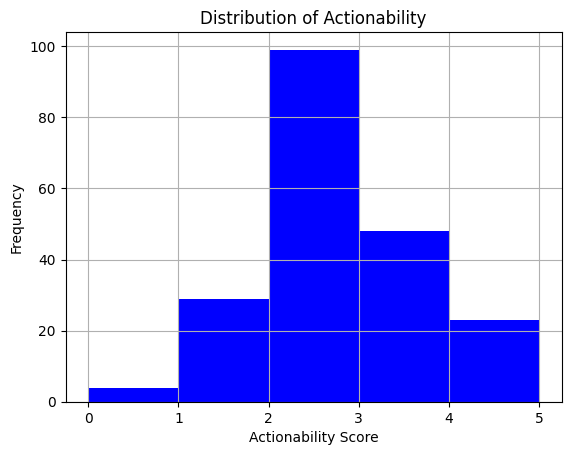

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# draw a histogram of the age column
ref_df['human_score_org_data'].hist(color='blue', bins=5, grid=True)

# add labels and title
plt.xlabel('Actionability Score')
plt.ylabel('Frequency')
plt.title('Distribution of Actionability')

In [ ]:
from google.colab import files
plt.savefig("data_distrib.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
!pwd

/content/drive/MyDrive/second_paper_insha_allah/data


mistral scores:

In [ ]:
prom_df = pd.DataFrame(columns=['prom_score_org_data', 'prom_score_mistral', 'prom_score_llama', 'prom_score_gpt'])
prom_score_org_data, prom_score_mistral, prom_score_llama, prom_score_gpt = seg_score(df.prom_eval.apply(format).to_list())

100%|██████████| 203/203 [00:00<00:00, 208636.05it/s]


In [ ]:
prom_df['prom_score_org_data']= prom_score_org_data
prom_df['prom_score_mistral'] = prom_score_mistral
prom_df['prom_score_llama'] = prom_score_llama
prom_df['prom_score_gpt'] = prom_score_gpt
prom_df.head()

,prom_score_org_data,prom_score_mistral,prom_score_llama,prom_score_gpt
0,1,3,4,5
1,3,2,4,4
2,2,4,3,4
3,1,3,3,3
4,2,4,3,3


fine_graned_act scores:

In [ ]:
fine_graned_act_df = pd.DataFrame(columns=['fine_grained_act_score_org_data', 'fine_grained_act_score_mistral', 'fine_grained_act_score_llama', 'fine_grained_act_score_gpt'])
fine_graned_act_score_org_data, fine_graned_act_score_mistral, fine_graned_act_score_llama, fine_graned_act_score_gpt = seg_score(df.FinGrAct_eval.apply(format).to_list())

100%|██████████| 203/203 [00:00<00:00, 516026.49it/s]


In [ ]:
fine_graned_act_df['fine_grained_act_score_org_data']= fine_graned_act_score_org_data
fine_graned_act_df['fine_grained_act_score_mistral'] = fine_graned_act_score_mistral
fine_graned_act_df['fine_grained_act_score_llama'] = fine_graned_act_score_llama
fine_graned_act_df['fine_grained_act_score_gpt'] = fine_graned_act_score_gpt
fine_graned_act_df.head()

,fine_grained_act_score_org_data,fine_grained_act_score_mistral,fine_grained_act_score_llama,fine_grained_act_score_gpt
0,5,5,5,5
1,2,3,5,3
2,3,3,3,3
3,3,3,3,2
4,0,3,3,3


geval scores:

In [ ]:
geval_df = pd.DataFrame(columns=['geval_score_org_data', 'geval_score_mistral', 'geval_score_llama', 'geval_score_gpt'])
geval_score_org_data, geval_score_mistral, geval_score_llama, geval_score_gpt = seg_score(df.geval_eval.apply(format).to_list())

100%|██████████| 203/203 [00:00<00:00, 205117.73it/s]


In [ ]:
geval_df['geval_score_org_data']= geval_score_org_data
geval_df['geval_score_mistral'] = geval_score_mistral
geval_df['geval_score_llama'] = geval_score_llama
geval_df['geval_score_gpt'] = geval_score_gpt
geval_df.head()

,geval_score_org_data,geval_score_mistral,geval_score_llama,geval_score_gpt
0,1,4,5,1
1,4,5,3,4
2,2,4,5,1
3,1,5,4,5
4,1,5,5,4


# human evaluation vs prom evaluation

In [ ]:
diff=  pd.DataFrame()
diff['prom-ref'] = prom_score_mistral - ref_df.human_score_mistral

In [ ]:
diff.columns

Index(['prom-ref'], dtype='object')

In [ ]:
diff[diff['prom-ref']>0]

,prom-ref
2,1
4,1
5,1
7,3
10,1
...,...
197,1
198,1
199,3
201,3


In [ ]:
diff[diff['prom-ref']>1], len(diff[diff['prom-ref']>1])

(     prom-ref
 7           3
 15          2
 16          2
 22          2
 24          2
 26          2
 31          2
 34          2
 35          2
 40          2
 49          2
 59          2
 63          2
 82          2
 94          2
 97          2
 100         3
 104         2
 105         2
 106         2
 108         2
 122         2
 123         2
 130         2
 133         2
 136         2
 145         3
 148         3
 155         3
 156         2
 157         2
 159         2
 160         2
 161         2
 162         3
 163         2
 165         2
 166         2
 167         2
 170         2
 171         2
 177         2
 178         2
 180         2
 182         2
 185         3
 186         2
 188         2
 195         3
 199         3
 201         3
 202         3,
 52)

In [ ]:
len(diff[diff['prom-ref']<0])

33

In [ ]:
diff[diff['prom-ref']<-1],len(diff[diff['prom-ref']<-1])

(     prom-ref
 0          -2
 112        -2
 116        -2
 117        -2
 118        -2
 125        -2
 126        -2
 134        -2
 137        -2
 140        -2,
 10)

# human evaluation vs fine_grained_act evaluation

In [ ]:
fine_graned_act_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   fine_grained_act_score_org_data  203 non-null    int64
 1   fine_grained_act_score_mistral   203 non-null    int64
 2   fine_grained_act_score_llama     203 non-null    int64
 3   fine_grained_act_score_gpt       203 non-null    int64
dtypes: int64(4)
memory usage: 6.5 KB


In [ ]:
diff=  pd.DataFrame()
diff['fine_grained-ref'] = fine_graned_act_df.fine_grained_act_score_gpt - ref_df.human_score_gpt

In [ ]:
diff.columns

Index(['fine_grained-ref'], dtype='object')

In [ ]:
diff[diff['fine_grained-ref']>0], len(diff[diff['fine_grained-ref']>0])

(     fine_grained-ref
 30                  1
 37                  1
 54                  1
 56                  1
 64                  1
 67                  1
 71                  1
 72                  1
 75                  1
 77                  1
 80                  1
 83                  1
 91                  1
 93                  1
 94                  3
 99                  2
 100                 1
 101                 2
 103                 1
 104                 2
 105                 2
 106                 2
 108                 2
 109                 3
 110                 2
 111                 2
 114                 3
 116                 2
 117                 2
 118                 1
 122                 2
 127                 2
 128                 4
 130                 1
 131                 1
 143                 1
 144                 2
 156                 1
 181                 1
 194                 1
 197                 1,
 41)

In [ ]:
diff[diff['fine_grained-ref']>1], len(diff[diff['fine_grained-ref']>1])

(     fine_grained-ref
 94                  3
 99                  2
 101                 2
 104                 2
 105                 2
 106                 2
 108                 2
 109                 3
 110                 2
 111                 2
 114                 3
 116                 2
 117                 2
 122                 2
 127                 2
 128                 4
 144                 2,
 17)

In [ ]:
len(diff[diff['fine_grained-ref']<0])

15

In [ ]:
diff[diff['fine_grained-ref']<-1],len(diff[diff['fine_grained-ref']<-1])

(     fine_grained-ref
 96                 -2
 123                -2
 161                -2
 202                -3,
 4)

# human evaluation vs geval evaluation

In [ ]:
diff=  pd.DataFrame()
diff['geval-ref'] = geval_score_gpt - ref_df.human_score_gpt

In [ ]:
diff.columns

Index(['geval-ref'], dtype='object')

In [ ]:
diff[diff['geval-ref']>0]

,geval-ref
3,2
4,1
5,1
6,1
7,2
...,...
197,2
199,2
200,2
201,1


In [ ]:
diff[diff['geval-ref']>1], len(diff[diff['geval-ref']>1])

(     geval-ref
 3            2
 7            2
 12           2
 14           2
 15           2
 ..         ...
 196          2
 197          2
 199          2
 200          2
 202          2
 
 [99 rows x 1 columns],
 99)

In [ ]:
len(diff[diff['geval-ref']<0])

24

In [ ]:
diff[diff['geval-ref']<-1],len(diff[diff['geval-ref']<-1])

(     geval-ref
 0           -4
 2           -2
 25          -2
 46          -2
 73          -2
 105         -2
 109         -2
 123         -3
 124         -2
 133         -2
 148         -2
 198         -2,
 12)